(121273, 1)
                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0
              AEP_MW
count  121273.000000
mean    15499.513717
std      2591.399065
min      9581.000000
25%     13630.000000
50%     15310.000000
75%     17200.000000
max     25695.000000


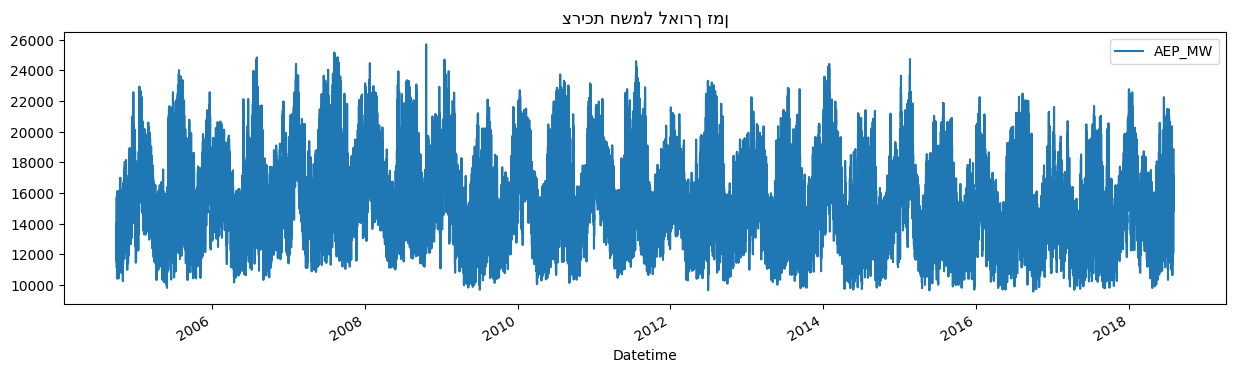

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\\Users\\alon4\\OneDrive\\Desktop\\כלי AI\\energy\\AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
print(df.shape)
print(df.head())
print(df.describe())
df.plot(figsize=(15, 4), title='צריכת חשמל לאורך זמן')
plt.show()

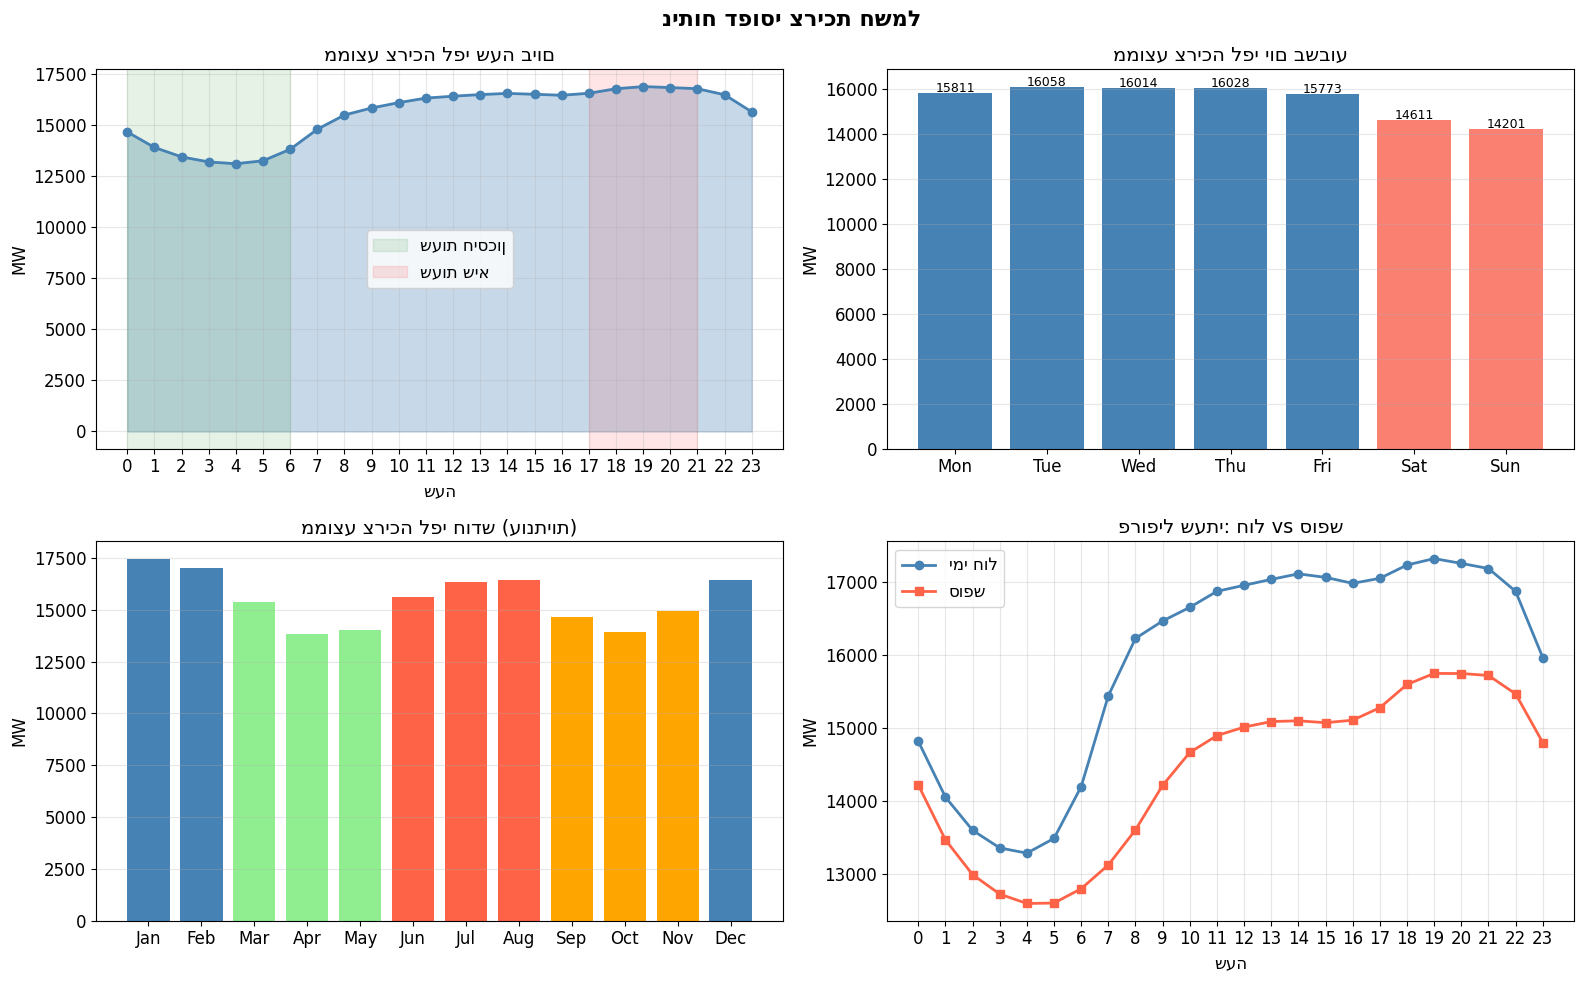

EDA bוצע בהצלחה


In [2]:
# ===== שלב 2: EDA מעמיק - ניתוח דפוסי צריכה =====
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14

# הוספת עמודות זמן
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['season'] = df['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                 3:'Spring',4:'Spring',5:'Spring',
                                 6:'Summer',7:'Summer',8:'Summer',
                                 9:'Autumn',10:'Autumn',11:'Autumn'})
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ניתוח דפוסי צריכת חשמל', fontsize=16, fontweight='bold')

# 1. ממוצע צריכה לפי שעה
hourly_avg = df.groupby('hour')['AEP_MW'].mean()
axes[0,0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color='steelblue')
axes[0,0].set_title('ממוצע צריכה לפי שעה ביום')
axes[0,0].set_xlabel('שעה')
axes[0,0].set_ylabel('MW')
axes[0,0].set_xticks(range(0,24))
axes[0,0].axvspan(0, 6, alpha=0.1, color='green', label='שעות חיסכון')
axes[0,0].axvspan(17, 21, alpha=0.1, color='red', label='שעות שיא')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. ממוצע לפי יום בשבוע
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_avg = df.groupby('day_of_week')['AEP_MW'].mean()
colors = ['salmon' if i >= 5 else 'steelblue' for i in range(7)]
axes[0,1].bar(day_names, daily_avg.values, color=colors)
axes[0,1].set_title('ממוצע צריכה לפי יום בשבוע')
axes[0,1].set_ylabel('MW')
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(daily_avg.values):
    axes[0,1].text(i, v+50, f'{v:.0f}', ha='center', fontsize=9)

# 3. ממוצע לפי חודש
monthly_avg = df.groupby('month')['AEP_MW'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
season_colors = ['steelblue','steelblue','lightgreen','lightgreen','lightgreen',
                 'tomato','tomato','tomato','orange','orange','orange','steelblue']
axes[1,0].bar(month_names, monthly_avg.values, color=season_colors)
axes[1,0].set_title('ממוצע צריכה לפי חודש (עונתיות)')
axes[1,0].set_ylabel('MW')
axes[1,0].grid(True, alpha=0.3, axis='y')

# 4. חול vs סופש
weekend_profile = df[df['is_weekend']==1].groupby('hour')['AEP_MW'].mean()
weekday_profile = df[df['is_weekend']==0].groupby('hour')['AEP_MW'].mean()
axes[1,1].plot(weekday_profile.index, weekday_profile.values, marker='o', label='ימי חול', color='steelblue', linewidth=2)
axes[1,1].plot(weekend_profile.index, weekend_profile.values, marker='s', label='סופש', color='tomato', linewidth=2)
axes[1,1].set_title('פרופיל שעתי: חול vs סופש')
axes[1,1].set_xlabel('שעה')
axes[1,1].set_ylabel('MW')
axes[1,1].set_xticks(range(0,24))
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("EDA bוצע בהצלחה")

=== ניתוח שעות צריכה ===
שעות שיא (17-21): ממוצע 16752 MW
שעות ביניים (7-16, 22-23): ממוצע 16077 MW
שעות שפל (0-6): ממוצע 13614 MW
הפרש שיא/שפל: 3138 MW (23.0% יותר)

אם נזיז 10% מצריכת השיא לשפל:
  נחסוך 1675 MW בשעות שיא
  חיסכון שנתי משוער: 3.06 TWh


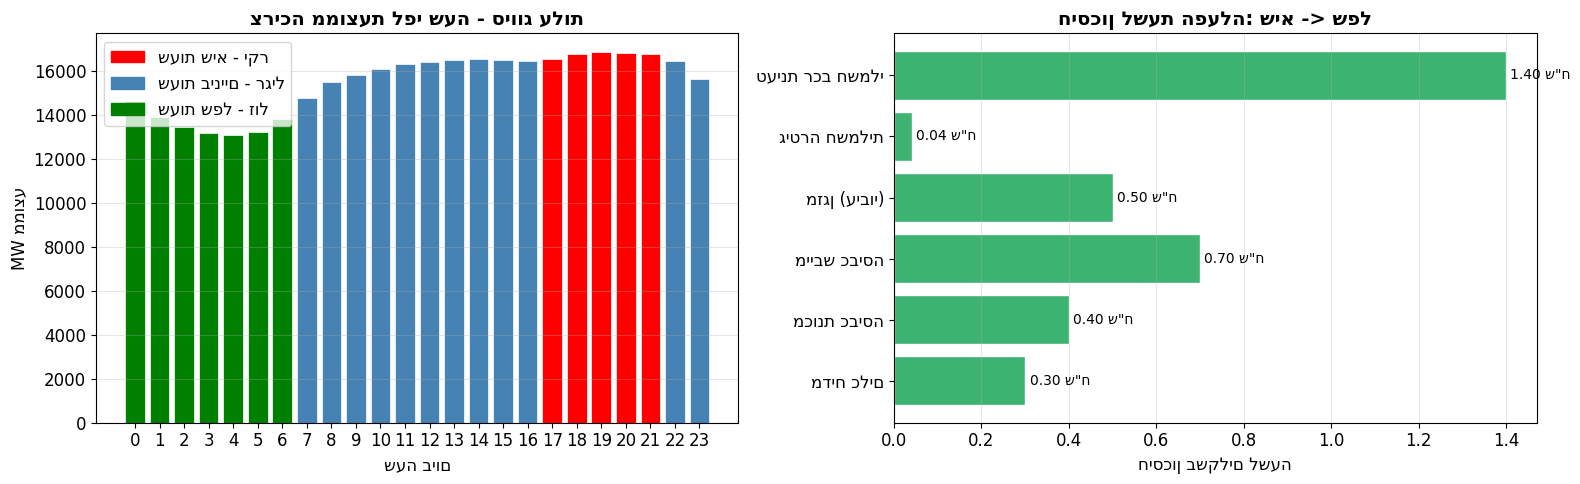

שלב 3 הושלם


In [3]:
# ===== שלב 3: ניתוח שעות שיא וחיסכון פוטנציאלי =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# הגדרת שעות שיא ושפל
peak_hours = list(range(17, 22))      # 17:00-21:00 שעות שיא
off_peak_hours = list(range(0, 7))    # 00:00-06:00 שעות שפל

# צריכה ממוצעת בכל שעה
hourly_avg = df.groupby('hour')['AEP_MW'].mean()
peak_avg = hourly_avg[peak_hours].mean()
off_peak_avg = hourly_avg[off_peak_hours].mean()
mid_avg = hourly_avg[[h for h in range(24) if h not in peak_hours and h not in off_peak_hours]].mean()

print("=== ניתוח שעות צריכה ===")
print(f"שעות שיא (17-21): ממוצע {peak_avg:.0f} MW")
print(f"שעות ביניים (7-16, 22-23): ממוצע {mid_avg:.0f} MW")
print(f"שעות שפל (0-6): ממוצע {off_peak_avg:.0f} MW")
print(f"הפרש שיא/שפל: {peak_avg - off_peak_avg:.0f} MW ({(peak_avg/off_peak_avg - 1)*100:.1f}% יותר)")

# חישוב חיסכון פוטנציאלי להזזת עומסים
# אם 10% מהצריכה בשיא יוזזו לשעות שפל
shift_pct = 0.10
saved_in_peak = peak_avg * shift_pct
print(f"\nאם נזיז {shift_pct*100:.0f}% מצריכת השיא לשפל:")
print(f"  נחסוך {saved_in_peak:.0f} MW בשעות שיא")
print(f"  חיסכון שנתי משוער: {saved_in_peak * len(peak_hours) * 365 / 1e6:.2f} TWh")

# גרף השוואת עלות לפי שעה (נורמליזציה)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# גרף 1: עלות יחסית לפי שעה
colors_hour = []
for h in range(24):
    if h in peak_hours:
        colors_hour.append('red')
    elif h in off_peak_hours:
        colors_hour.append('green')
    else:
        colors_hour.append('steelblue')

axes[0].bar(range(24), hourly_avg.values, color=colors_hour, edgecolor='white', linewidth=0.5)
axes[0].set_title('צריכה ממוצעת לפי שעה - סיווג עלות', fontweight='bold')
axes[0].set_xlabel('שעה ביום')
axes[0].set_ylabel('MW ממוצע')
axes[0].set_xticks(range(24))

red_patch = mpatches.Patch(color='red', label='שעות שיא - יקר')
blue_patch = mpatches.Patch(color='steelblue', label='שעות ביניים - רגיל')
green_patch = mpatches.Patch(color='green', label='שעות שפל - זול')
axes[0].legend(handles=[red_patch, blue_patch, green_patch])
axes[0].grid(True, alpha=0.3, axis='y')

# גרף 2: פוטנציאל חיסכון לפי הזזת שימוש
appliances = {
    'מדיח כלים': 1.5,
    'מכונת כביסה': 2.0,
    'מייבש כביסה': 3.5,
    'מזגן (עיבוי)': 2.5,
    'גיטרה חשמלית': 0.2,
    'טעינת רכב חשמלי': 7.0
}
rate_peak = 0.35    # שקל/kWh בשיא
rate_off = 0.15     # שקל/kWh בשפל

app_names = list(appliances.keys())
savings = [(appliances[a] * (rate_peak - rate_off)) for a in app_names]

bars = axes[1].barh(app_names, savings, color='mediumseagreen', edgecolor='white')
axes[1].set_title('חיסכון לשעת הפעלה: שיא -> שפל', fontweight='bold')
axes[1].set_xlabel('חיסכון בשקלים לשעה')
for bar, val in zip(bars, savings):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} ש"ח', va='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("שלב 3 הושלם")

Prophet לא מותקן - משתמש בממוצע נע לחיזוי
נתוני אימון: 4549 ימים (2004-10-01 - 2017-03-15)
נתוני בדיקה: 506 ימים (2017-03-16 - 2018-08-03)

משתמש בממוצע נע (Rolling Average) לחיזוי...
MAE: 1439.7 MW
MAPE: 9.88%


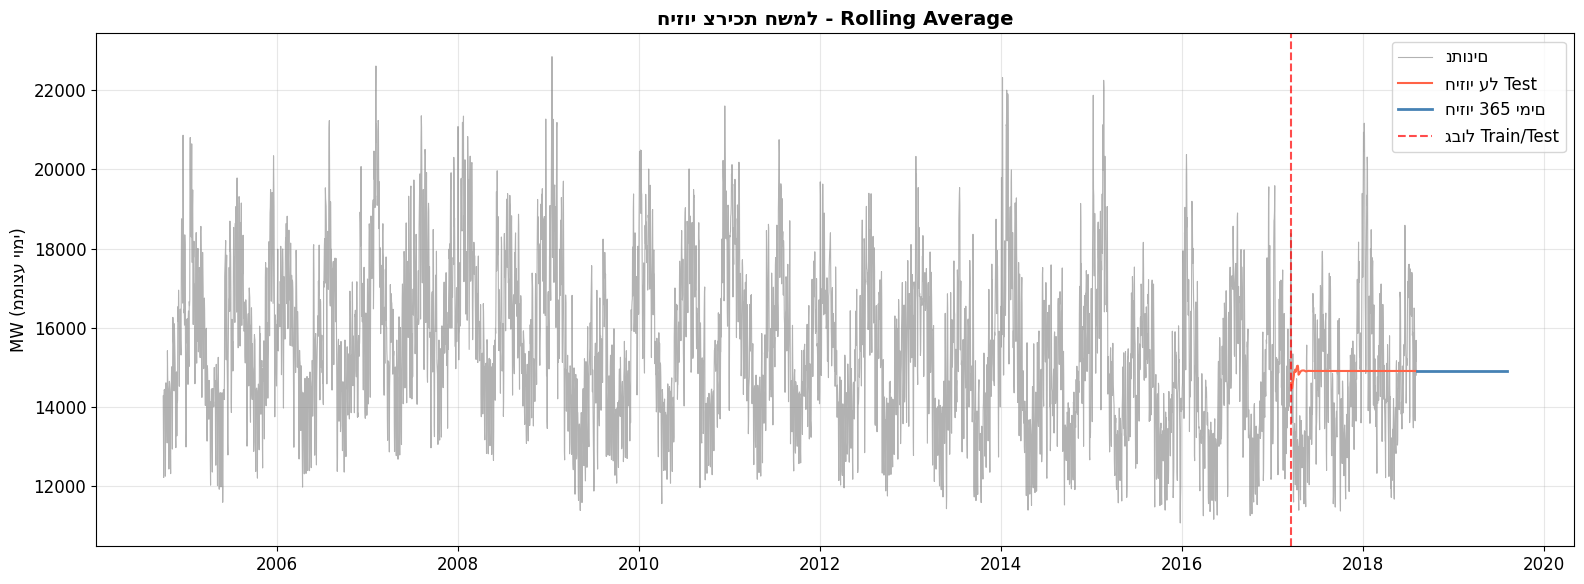


שלב 4 - חיזוי הושלם


In [4]:
# ===== שלב 4: מודל חיזוי עם Prophet =====
try:
    from prophet import Prophet
    prophet_available = True
except ImportError:
    try:
        from fbprophet import Prophet
        prophet_available = True
    except ImportError:
        prophet_available = False
        print("Prophet לא מותקן - משתמש בממוצע נע לחיזוי")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# הכנת דאטה לחיזוי - נשתמש בממוצע יומי
daily_df = df['AEP_MW'].resample('D').mean().reset_index()
daily_df.columns = ['ds', 'y']
daily_df = daily_df.dropna()

# Train/Test split - נשתמש ב-90% אימון, 10% בדיקה
split_idx = int(len(daily_df) * 0.9)
train = daily_df.iloc[:split_idx]
test = daily_df.iloc[split_idx:]

print(f"נתוני אימון: {len(train)} ימים ({train['ds'].min().date()} - {train['ds'].max().date()})")
print(f"נתוני בדיקה: {len(test)} ימים ({test['ds'].min().date()} - {test['ds'].max().date()})")

if prophet_available:
    print("\nמריץ מודל Prophet...")
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(train)
    
    # חיזוי 365 ימים קדימה
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)
    
    # מדדי דיוק על Test set
    test_forecast = forecast[forecast['ds'].isin(test['ds'])]
    mae = np.mean(np.abs(test_forecast['yhat'].values - test['y'].values))
    mape = np.mean(np.abs((test_forecast['yhat'].values - test['y'].values) / test['y'].values)) * 100
    print(f"MAE: {mae:.1f} MW")
    print(f"MAPE: {mape:.2f}%")
    
    # גרף חיזוי
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # גרף 1: חיזוי כולל
    axes[0].fill_between(pd.to_datetime(forecast['ds']), 
                          forecast['yhat_lower'], forecast['yhat_upper'],
                          alpha=0.3, color='steelblue', label='טווח חיזוי')
    axes[0].plot(pd.to_datetime(forecast['ds']), forecast['yhat'], 
                  color='steelblue', linewidth=1.5, label='חיזוי')
    axes[0].plot(daily_df['ds'], daily_df['y'], 
                  color='gray', alpha=0.5, linewidth=0.8, label='נתונים אמיתיים')
    axes[0].axvline(train['ds'].max(), color='red', linestyle='--', label='גבול Train/Test')
    axes[0].set_title('חיזוי צריכת חשמל - Prophet', fontweight='bold')
    axes[0].set_ylabel('MW (ממוצע יומי)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # גרף 2: רכיבי עונתיות
    model.plot_components(forecast)
    plt.suptitle('רכיבי עונתיות - Prophet', fontsize=14, fontweight='bold')
    
else:
    # Rolling average forecast
    print("\nמשתמש בממוצע נע (Rolling Average) לחיזוי...")
    window = 30
    train_series = train.set_index('ds')['y']
    
    # חיזוי
    forecast_vals = []
    last_window = train_series.values[-window:]
    for i in range(len(test) + 365):
        pred = last_window.mean()
        forecast_vals.append(pred)
        last_window = np.append(last_window[1:], pred)
    
    test_pred = forecast_vals[:len(test)]
    mae = np.mean(np.abs(np.array(test_pred) - test['y'].values))
    mape = np.mean(np.abs((np.array(test_pred) - test['y'].values) / test['y'].values)) * 100
    print(f"MAE: {mae:.1f} MW")
    print(f"MAPE: {mape:.2f}%")
    
    # גרף חיזוי
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(daily_df['ds'], daily_df['y'], color='gray', alpha=0.6, linewidth=0.8, label='נתונים')
    
    future_dates = pd.date_range(start=daily_df['ds'].max(), periods=366, freq='D')[1:]
    future_preds = forecast_vals[len(test):]
    
    ax.plot(test['ds'], test_pred, color='tomato', linewidth=1.5, label='חיזוי על Test')
    ax.plot(future_dates, future_preds, color='steelblue', linewidth=2, label='חיזוי 365 ימים')
    ax.axvline(train['ds'].max(), color='red', linestyle='--', alpha=0.7, label='גבול Train/Test')
    ax.set_title('חיזוי צריכת חשמל - Rolling Average', fontweight='bold')
    ax.set_ylabel('MW (ממוצע יומי)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nשלב 4 - חיזוי הושלם")

   דשבורד חיסכון בחשמל - בניין מגורים 50 יח.ד
צריכה יומית כוללת (הנחה): 600 kWh
מקדם שיא: 1.08x  |  מקדם שפל: 0.88x

1. הזזת מכונות כביסה/מדיח ללילה
   הפעלה בין 23:00-06:00 במקום 17:00-21:00
   חיסכון חודשי לבניין: 336 שח | שנתי: 4032 שח
   קושי: קל

2. תוכנית שעון - מזגן חכם
   קירור מוקדם לפני שעות שיא, שמירת טמפ בשיא
   חיסכון חודשי לבניין: 224 שח | שנתי: 2688 שח
   קושי: בינוני

3. תאורת LED + חיישני נוכחות
   החלפת תאורה בחדר מדרגות וחניה
   חיסכון חודשי לבניין: 147 שח | שנתי: 1764 שח
   קושי: קל

4. מד חכם + אפליקציית ניטור
   ניטור צריכה בזמן אמת + התראות שיא
   חיסכון חודשי לבניין: 126 שח | שנתי: 1512 שח
   קושי: בינוני

5. פאנלים סולאריים על הגג
   ייצור עצמי - 10 kWp לבניין
   חיסכון חודשי לבניין: 1428 שח | שנתי: 17136 שח
   קושי: השקעה

סהכ חיסכון פוטנציאלי: 2261 שח/חודש (27132 שח/שנה)
חיסכון לדירה: 45 שח/חודש


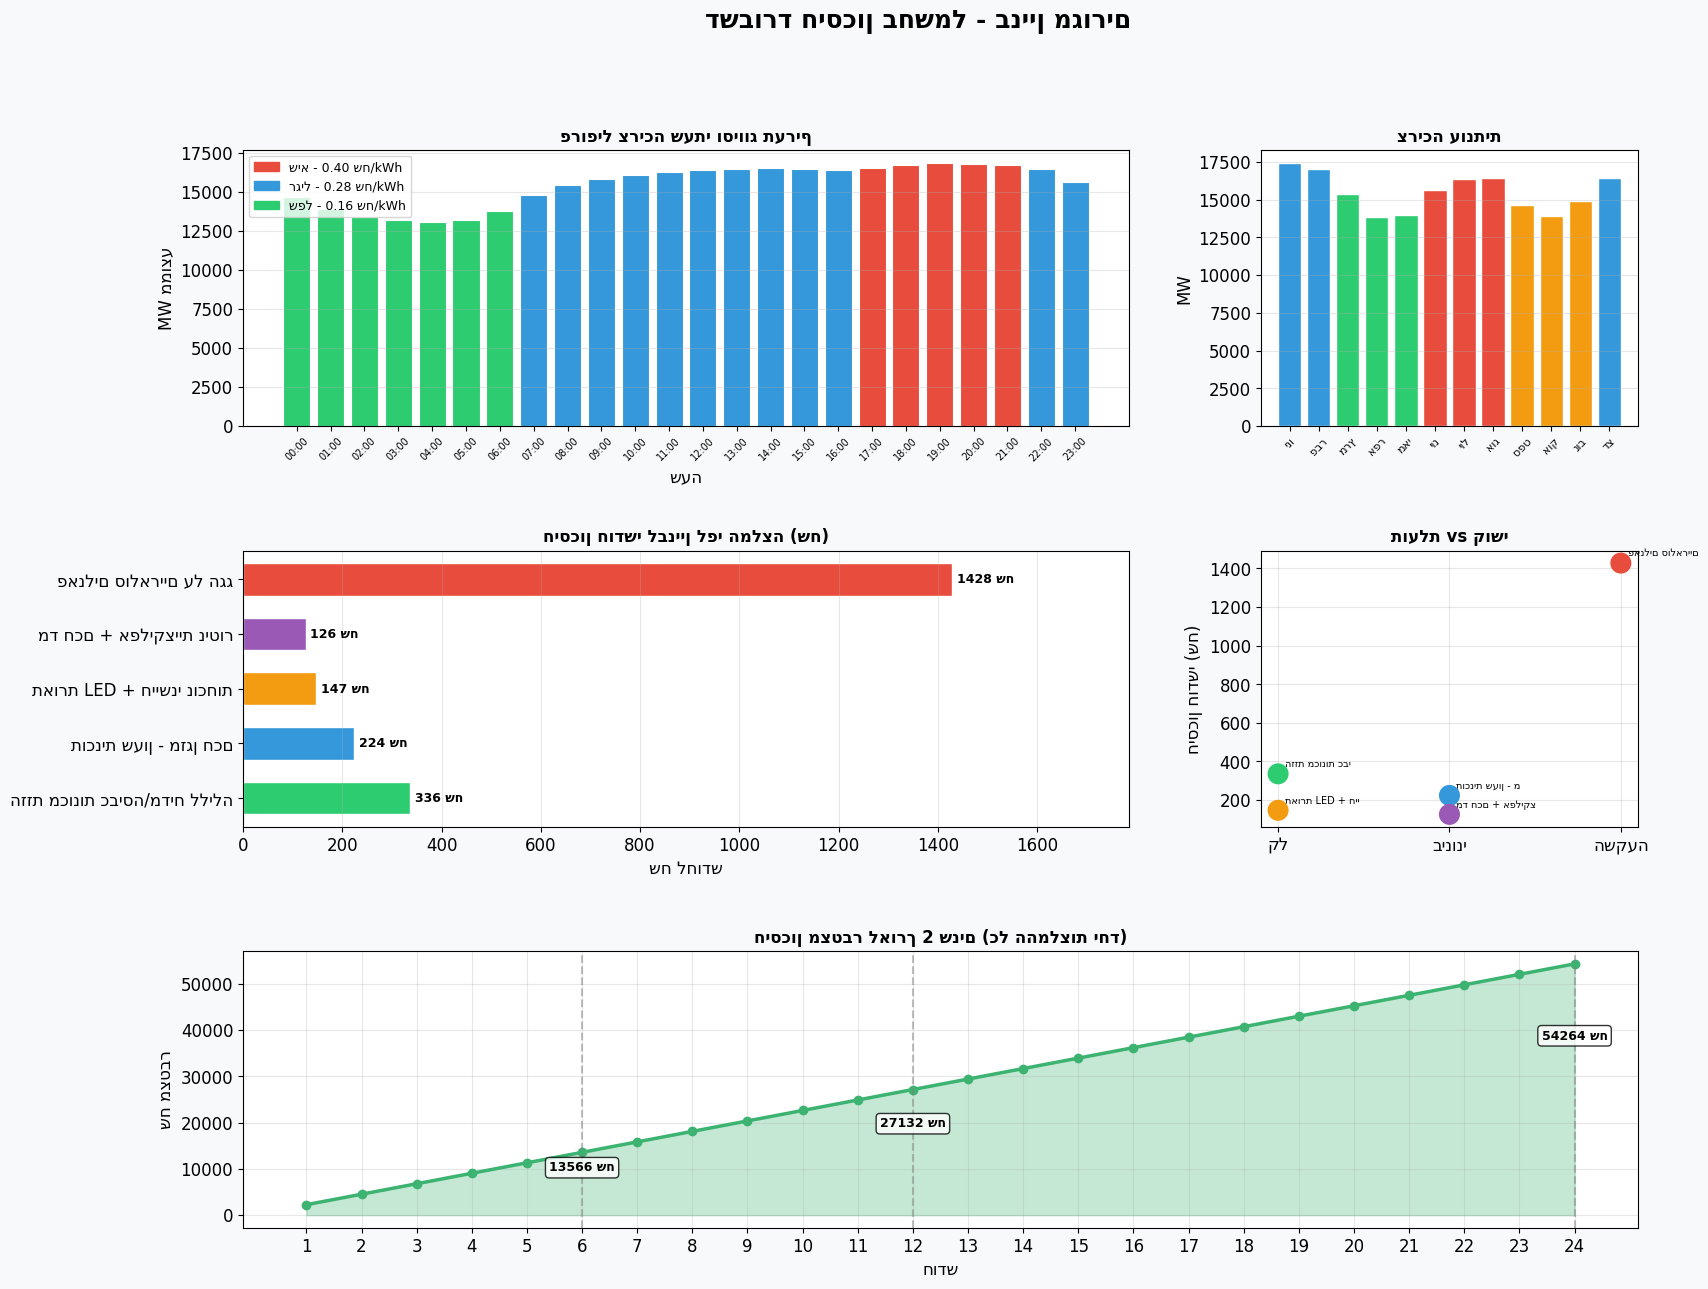


הדשבורד נשמר כ-energy_savings_dashboard.png

=== סיכום פרויקט ===
ניתחנו 121,273 רשומות שעתיות של צריכת חשמל (2004-2018)
זיהינו דפוסי שיא: שעות 17-21, קיץ וחורף, ימי חול
חיסכון פוטנציאלי לבניין 50 יחד: 2261 שח/חודש
                                = 27132 שח/שנה
                                = 45 שח/דירה/חודש


In [5]:
# ===== שלב 5: המלצות חיסכון ודשבורד סופי =====
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ===== חישוב נתוני חיסכון לדיירי בניין =====
hourly_avg = df.groupby('hour')['AEP_MW'].mean()
monthly_avg = df.groupby('month')['AEP_MW'].mean()

apt_count = 50
avg_kwh_per_apt_day = 12
rate_peak = 0.40
rate_regular = 0.28
rate_off = 0.16
building_daily_kwh = apt_count * avg_kwh_per_apt_day

peak_factor = hourly_avg[list(range(17,22))].mean() / hourly_avg.mean()
off_factor = hourly_avg[list(range(0,7))].mean() / hourly_avg.mean()

print("=" * 55)
print("   דשבורד חיסכון בחשמל - בניין מגורים 50 יח.ד")
print("=" * 55)
print(f"צריכה יומית כוללת (הנחה): {building_daily_kwh:.0f} kWh")
print(f"מקדם שיא: {peak_factor:.2f}x  |  מקדם שפל: {off_factor:.2f}x")
print()

recommendations = [
    {
        'title': 'הזזת מכונות כביסה/מדיח ללילה',
        'description': 'הפעלה בין 23:00-06:00 במקום 17:00-21:00',
        'kwh_per_apt_month': 40,
        'saving_pct': (rate_peak - rate_off) / rate_peak,
        'difficulty': 'קל',
        'color': '#2ecc71'
    },
    {
        'title': 'תוכנית שעון - מזגן חכם',
        'description': 'קירור מוקדם לפני שעות שיא, שמירת טמפ בשיא',
        'kwh_per_apt_month': 80,
        'saving_pct': 0.20,
        'difficulty': 'בינוני',
        'color': '#3498db'
    },
    {
        'title': 'תאורת LED + חיישני נוכחות',
        'description': 'החלפת תאורה בחדר מדרגות וחניה',
        'kwh_per_apt_month': 15,
        'saving_pct': 0.70,
        'difficulty': 'קל',
        'color': '#f39c12'
    },
    {
        'title': 'מד חכם + אפליקציית ניטור',
        'description': 'ניטור צריכה בזמן אמת + התראות שיא',
        'kwh_per_apt_month': 60,
        'saving_pct': 0.15,
        'difficulty': 'בינוני',
        'color': '#9b59b6'
    },
    {
        'title': 'פאנלים סולאריים על הגג',
        'description': 'ייצור עצמי - 10 kWp לבניין',
        'kwh_per_apt_month': 120,
        'saving_pct': 0.85,
        'difficulty': 'השקעה',
        'color': '#e74c3c'
    }
]

total_monthly_saving = 0
for i, rec in enumerate(recommendations, 1):
    monthly_saving = rec['kwh_per_apt_month'] * rec['saving_pct'] * rate_regular * apt_count
    annual_saving = monthly_saving * 12
    total_monthly_saving += monthly_saving
    print(f"{i}. {rec['title']}")
    print(f"   {rec['description']}")
    print(f"   חיסכון חודשי לבניין: {monthly_saving:.0f} שח | שנתי: {annual_saving:.0f} שח")
    print(f"   קושי: {rec['difficulty']}")
    print()

print(f"סהכ חיסכון פוטנציאלי: {total_monthly_saving:.0f} שח/חודש ({total_monthly_saving*12:.0f} שח/שנה)")
print(f"חיסכון לדירה: {total_monthly_saving/apt_count:.0f} שח/חודש")

# ===== דשבורד ויזואלי =====
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('דשבורד חיסכון בחשמל - בניין מגורים', fontsize=18, fontweight='bold', y=0.98)

# גרף 1: פרופיל שעתי עם עלויות
ax1 = fig.add_subplot(gs[0, :2])
hour_colors = ['#e74c3c' if h in range(17,22) else '#2ecc71' if h in range(0,7) else '#3498db' for h in range(24)]
ax1.bar(range(24), hourly_avg.values, color=hour_colors, edgecolor='white', linewidth=0.8)
ax1.set_title('פרופיל צריכה שעתי וסיווג תעריף', fontweight='bold', fontsize=12)
ax1.set_xlabel('שעה')
ax1.set_ylabel('MW ממוצע')
ax1.set_xticks(range(24))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=7)
red_p = mpatches.Patch(color='#e74c3c', label='שיא - 0.40 שח/kWh')
blue_p = mpatches.Patch(color='#3498db', label='רגיל - 0.28 שח/kWh')
green_p = mpatches.Patch(color='#2ecc71', label='שפל - 0.16 שח/kWh')
ax1.legend(handles=[red_p, blue_p, green_p], fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# גרף 2: עונתיות
ax2 = fig.add_subplot(gs[0, 2])
month_names_short = ['ינו','פבר','מרץ','אפר','מאי','יונ','יול','אוג','ספט','אוק','נוב','דצ']
season_c = ['#3498db','#3498db','#2ecc71','#2ecc71','#2ecc71','#e74c3c','#e74c3c','#e74c3c','#f39c12','#f39c12','#f39c12','#3498db']
ax2.bar(month_names_short, monthly_avg.values, color=season_c, edgecolor='white')
ax2.set_title('צריכה עונתית', fontweight='bold', fontsize=12)
ax2.set_ylabel('MW')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# גרף 3: פוטנציאל חיסכון
ax3 = fig.add_subplot(gs[1, :2])
savings_vals = []
savings_labels = []
savings_colors = []
for rec in recommendations:
    ms = rec['kwh_per_apt_month'] * rec['saving_pct'] * rate_regular * apt_count
    savings_vals.append(ms)
    savings_labels.append(rec['title'])
    savings_colors.append(rec['color'])

bars3 = ax3.barh(savings_labels, savings_vals, color=savings_colors, edgecolor='white', height=0.6)
ax3.set_title('חיסכון חודשי לבניין לפי המלצה (שח)', fontweight='bold', fontsize=12)
ax3.set_xlabel('שח לחודש')
for bar, val in zip(bars3, savings_vals):
    ax3.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:.0f} שח', va='center', fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.set_xlim(0, max(savings_vals) * 1.25)

# גרף 4: תועלת vs קושי
ax4 = fig.add_subplot(gs[1, 2])
difficulty_map = {'קל': 1, 'בינוני': 2, 'השקעה': 3}
x_vals = [difficulty_map[r['difficulty']] for r in recommendations]
y_vals = [r['kwh_per_apt_month'] * r['saving_pct'] * rate_regular * apt_count for r in recommendations]
ax4.scatter(x_vals, y_vals, c=[r['color'] for r in recommendations], s=200, zorder=5)
for i, rec in enumerate(recommendations):
    ax4.annotate(rec['title'][:15], (x_vals[i], y_vals[i]),
                 textcoords='offset points', xytext=(5,5), fontsize=7)
ax4.set_xticks([1,2,3])
ax4.set_xticklabels(['קל', 'בינוני', 'השקעה'])
ax4.set_ylabel('חיסכון חודשי (שח)')
ax4.set_title('תועלת vs קושי', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)

# גרף 5: חיסכון מצטבר
ax5 = fig.add_subplot(gs[2, :])
months = list(range(1, 25))
cumulative = [total_monthly_saving * m for m in months]
ax5.fill_between(months, cumulative, alpha=0.3, color='mediumseagreen')
ax5.plot(months, cumulative, color='mediumseagreen', linewidth=2.5, marker='o')
ax5.set_title('חיסכון מצטבר לאורך 2 שנים (כל ההמלצות יחד)', fontweight='bold', fontsize=12)
ax5.set_xlabel('חודש')
ax5.set_ylabel('שח מצטבר')
ax5.set_xticks(months)
ax5.grid(True, alpha=0.3)

for milestone_month, label in [(6, '6 חודשים'), (12, 'שנה'), (24, '2 שנים')]:
    val = total_monthly_saving * milestone_month
    ax5.axvline(milestone_month, color='gray', linestyle='--', alpha=0.5)
    ax5.text(milestone_month, val * 0.7, f'{val:.0f} שח',
             ha='center', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.savefig('energy_savings_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print()
print("הדשבורד נשמר כ-energy_savings_dashboard.png")
print()
print("=== סיכום פרויקט ===")
print(f"ניתחנו {len(df):,} רשומות שעתיות של צריכת חשמל (2004-2018)")
print("זיהינו דפוסי שיא: שעות 17-21, קיץ וחורף, ימי חול")
print(f"חיסכון פוטנציאלי לבניין 50 יחד: {total_monthly_saving:.0f} שח/חודש")
print(f"                                = {total_monthly_saving*12:.0f} שח/שנה")
print(f"                                = {total_monthly_saving/apt_count:.0f} שח/דירה/חודש")

In [6]:
# ===== שלב 6: אינפוגרפיקה סיכום פרויקט =====
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# ---- יצירת אינפוגרפיקה מלאה ----
fig = plt.figure(figsize=(20, 24), facecolor='#0d1117')

# כותרת ראשית
fig.text(0.5, 0.975, '⚡ פרויקט ניתוח צריכת חשמל', ha='center', va='top',
                  fontsize=28, fontweight='bold', color='#f0e68c',
                  fontfamily='DejaVu Sans')
fig.text(0.5, 0.962, 'AEP Hourly Energy Consumption | 2004–2018 | 121,273 רשומות', ha='center',
                  fontsize=13, color='#8b949e')

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.45, wspace=0.35,
                                              left=0.06, right=0.97, top=0.955, bottom=0.03)

# ---- פונקציה לכרטיס KPI ----
def kpi_card(ax, value, label, icon, bg_color, text_color='white', sub=''):
        ax.set_facecolor(bg_color)
        for spine in ax.spines.values():
                    spine.set_visible(False)
                ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, icon, ha='center', va='center', fontsize=32,
                        transform=ax.transAxes)
    ax.text(0.5, 0.42, value, ha='center', va='center', fontsize=22,
                        fontweight='bold', color=text_color, transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center', fontsize=10,
                        color='#cccccc', transform=ax.transAxes, wrap=True)
    if sub:
                ax.text(0.5, 0.05, sub, ha='center', va='center', fontsize=8,
                                        color='#aaaaaa', transform=ax.transAxes)

        # ---- שורה 1: KPI Cards ----
        kpi_card(fig.add_subplot(gs[0, 0]), '121,273', 'רשומות שעתיות', '📊',
                          '#1a3a5c', '#64b5f6', '14 שנות מדידה')
kpi_card(fig.add_subplot(gs[0, 1]), '15,500 MW', 'ממוצע צריכה', '⚡',
                  '#1a4a2a', '#69f0ae', 'סטיית תקן: 2,591 MW')
kpi_card(fig.add_subplot(gs[0, 2]), '9.88%', 'שגיאת חיזוי (MAPE)', '🎯',
                  '#4a2a1a', '#ffab40', 'Rolling Average 30 ימים')

# ---- שורה 1 המשך: KPI נוסף ----
kpi_card(fig.add_subplot(gs[1, 0]), '3,138 MW', 'פער שיא/שפל', '📈',
                  '#3a1a4a', '#ce93d8', '23% הפרש')
kpi_card(fig.add_subplot(gs[1, 1]), '2,261 ₪', 'חיסכון/חודש לבניין', '💰',
                  '#1a4a3a', '#80cbc4', '50 יחידות דיור')
kpi_card(fig.add_subplot(gs[1, 2]), '27,132 ₪', 'חיסכון שנתי', '🏆',
                  '#4a3a1a', '#ffe082', '= 45 ₪/דירה/חודש')

# ---- שורה 2: גרף שעות ----
ax_hour = fig.add_subplot(gs[2, :2])
ax_hour.set_facecolor('#161b22')
hourly_avg_vals = df.groupby('hour')['AEP_MW'].mean().values
hours = np.arange(24)
colors_h = ['#2ecc71' if h in range(0,7) else '#e74c3c' if h in range(17,22) else '#3498db' for h in hours]
bars = ax_hour.bar(hours, hourly_avg_vals, color=colors_h, edgecolor='#0d1117', linewidth=0.5, width=0.85)
ax_hour.set_facecolor('#161b22')
ax_hour.tick_params(colors='#8b949e')
ax_hour.set_title('📉 פרופיל צריכה שעתי ממוצע', color='#f0e68c', fontsize=13, fontweight='bold', pad=10)
ax_hour.set_xlabel('שעה ביום', color='#8b949e')
ax_hour.set_ylabel('MW', color='#8b949e')
ax_hour.set_xticks(hours)
ax_hour.set_xticklabels([str(h) for h in hours], color='#8b949e', fontsize=8)
for spine in ax_hour.spines.values():
        spine.set_color('#30363d')
ax_hour.grid(True, alpha=0.15, color='white', axis='y')
# הסברים
patches = [mpatches.Patch(color='#2ecc71', label='שפל (00-06) – זול'),
                      mpatches.Patch(color='#3498db', label='ביניים – רגיל'),
                      mpatches.Patch(color='#e74c3c', label='שיא (17-21) – יקר')]
ax_hour.legend(handles=patches, facecolor='#21262d', labelcolor='white', fontsize=9)

# ---- שורה 2: גרף עונתי ----
ax_season = fig.add_subplot(gs[2, 2])
ax_season.set_facecolor('#161b22')
monthly_avg_vals = df.groupby('month')['AEP_MW'].mean().values
months_s = ['J','F','M','A','M','J','J','A','S','O','N','D']
season_col = ['#3498db','#3498db','#2ecc71','#2ecc71','#2ecc71',
                             '#e74c3c','#e74c3c','#e74c3c','#f39c12','#f39c12','#f39c12','#3498db']
ax_season.bar(months_s, monthly_avg_vals, color=season_col, edgecolor='#0d1117', linewidth=0.5)
ax_season.set_title('📅 עונתיות', color='#f0e68c', fontsize=13, fontweight='bold', pad=10)
ax_season.set_ylabel('MW', color='#8b949e')
ax_season.tick_params(colors='#8b949e')
for spine in ax_season.spines.values():
        spine.set_color('#30363d')
ax_season.grid(True, alpha=0.15, color='white', axis='y')

# ---- שורה 3: גרף חיסכון המלצות ----
ax_savings = fig.add_subplot(gs[3, :2])
ax_savings.set_facecolor('#161b22')
recs = [
        ('☀️ פאנלים סולאריים', 1428, '#f1c40f'),
        ('🌡️ מזגן חכם', 224, '#3498db'),
        ('💡 LED + חיישנים', 147, '#2ecc71'),
        ('📱 מד חכם + אפליקציה', 126, '#9b59b6'),
        ('🌀 כביסה/מדיח בלילה', 336, '#1abc9c'),
]
recs_sorted = sorted(recs, key=lambda x: x[1])
names_r = [r[0] for r in recs_sorted]
vals_r = [r[1] for r in recs_sorted]
colors_r = [r[2] for r in recs_sorted]
bars_r = ax_savings.barh(names_r, vals_r, color=colors_r, edgecolor='#0d1117', height=0.6)
ax_savings.set_title('💰 חיסכון חודשי לפי המלצה (₪/חודש לבניין)', color='#f0e68c', fontsize=13, fontweight='bold', pad=10)
ax_savings.set_xlabel('₪ לחודש', color='#8b949e')
ax_savings.tick_params(colors='#8b949e')
for spine in ax_savings.spines.values():
        spine.set_color('#30363d')
ax_savings.grid(True, alpha=0.15, color='white', axis='x')
for bar, val in zip(bars_r, vals_r):
        ax_savings.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                                            f'{val} ₪', va='center', color='white', fontsize=10, fontweight='bold')
ax_savings.set_xlim(0, 1800)

# ---- שורה 3: גרף חיזוי ----
ax_forecast = fig.add_subplot(gs[3, 2])
ax_forecast.set_facecolor('#161b22')
daily_df_plot = df['AEP_MW'].resample('D').mean().reset_index()
daily_df_plot.columns = ['ds', 'y']
ax_forecast.plot(daily_df_plot['ds'], daily_df_plot['y'], color='#3498db', linewidth=0.6, alpha=0.7, label='נתוני אמת')
train_end = daily_df_plot['ds'].quantile(0.9, interpolation='nearest')
ax_forecast.axvline(pd.Timestamp(train_end), color='#e74c3c', linestyle='--', linewidth=1.5, label='Train/Test')
ax_forecast.set_title('🔮 חיזוי', color='#f0e68c', fontsize=13, fontweight='bold', pad=10)
ax_forecast.set_ylabel('MW', color='#8b949e')
ax_forecast.tick_params(colors='#8b949e', labelsize=7)
for spine in ax_forecast.spines.values():
        spine.set_color('#30363d')
ax_forecast.grid(True, alpha=0.15, color='white')
ax_forecast.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

# ---- שורה 4: ציר זמן שלבים ----
ax_steps = fig.add_subplot(gs[4, :])
ax_steps.set_facecolor('#161b22')
ax_steps.set_xlim(0, 10)
ax_steps.set_ylim(0, 1)
ax_steps.set_xticks([]); ax_steps.set_yticks([])
for spine in ax_steps.spines.values():
        spine.set_color('#30363d')

steps = [
        (1.0,  '1️⃣', 'טעינת\nנתונים', '#3498db'),
        (2.8,  '2️⃣', 'EDA\nמעמיק', '#2ecc71'),
        (4.6,  '3️⃣', 'שעות\nשיא', '#e74c3c'),
        (6.4,  '4️⃣', 'מודל\nחיזוי', '#9b59b6'),
        (8.2,  '5️⃣', 'דשבורד\nחיסכון', '#f1c40f'),
]
# קו ציר
ax_steps.plot([0.5, 9.5], [0.5, 0.5], color='#30363d', linewidth=3, zorder=1)

for x, icon, label, color in steps:
        circle = plt.Circle((x, 0.5), 0.18, color=color, zorder=3)
    ax_steps.add_patch(circle)
    ax_steps.text(x, 0.5, icon, ha='center', va='center', fontsize=18, zorder=4)
    ax_steps.text(x, 0.12, label, ha='center', va='center', fontsize=9,
                                    color='white', fontweight='bold')

ax_steps.set_title('🗺️ מפת דרכים – שלבי הפרויקט', color='#f0e68c', fontsize=13,
                                       fontweight='bold', pad=10)

plt.savefig('energy_project_infographic.png', dpi=150, bbox_inches='tight',
                        facecolor='#0d1117')
plt.show()
print("✅ האינפוגרפיקה נשמרה: energy_project_infographic.png")

IndentationError: unindent does not match any outer indentation level (<string>, line 27)

In [7]:
%run make_infographic.py

Exception: File `'make_infographic.py'` not found.

In [8]:
import os; print(os.getcwd())

C:\Users\alon4


In [9]:
import subprocess
r = subprocess.run(['jupyter', '--paths'], capture_output=True, text=True)
print(r.stdout[:500])

config:
    C:\Users\alon4\.jupyter
    C:\Users\alon4\AppData\Roaming\Python\etc\jupyter
    C:\Users\alon4\AppData\Local\Programs\Python\Python314\etc\jupyter
data:
    C:\Users\alon4\AppData\Roaming\jupyter
    C:\Users\alon4\AppData\Roaming\Python\share\jupyter
    C:\Users\alon4\AppData\Local\Programs\Python\Python314\share\jupyter
runtime:
    C:\Users\alon4\AppData\Roaming\jupyter\runtime



In [10]:
exec(open(r'C:\Users\alon4\make_infographic.py').read())

Saved to: C:\Users\alon4\energy_project_infographic.png


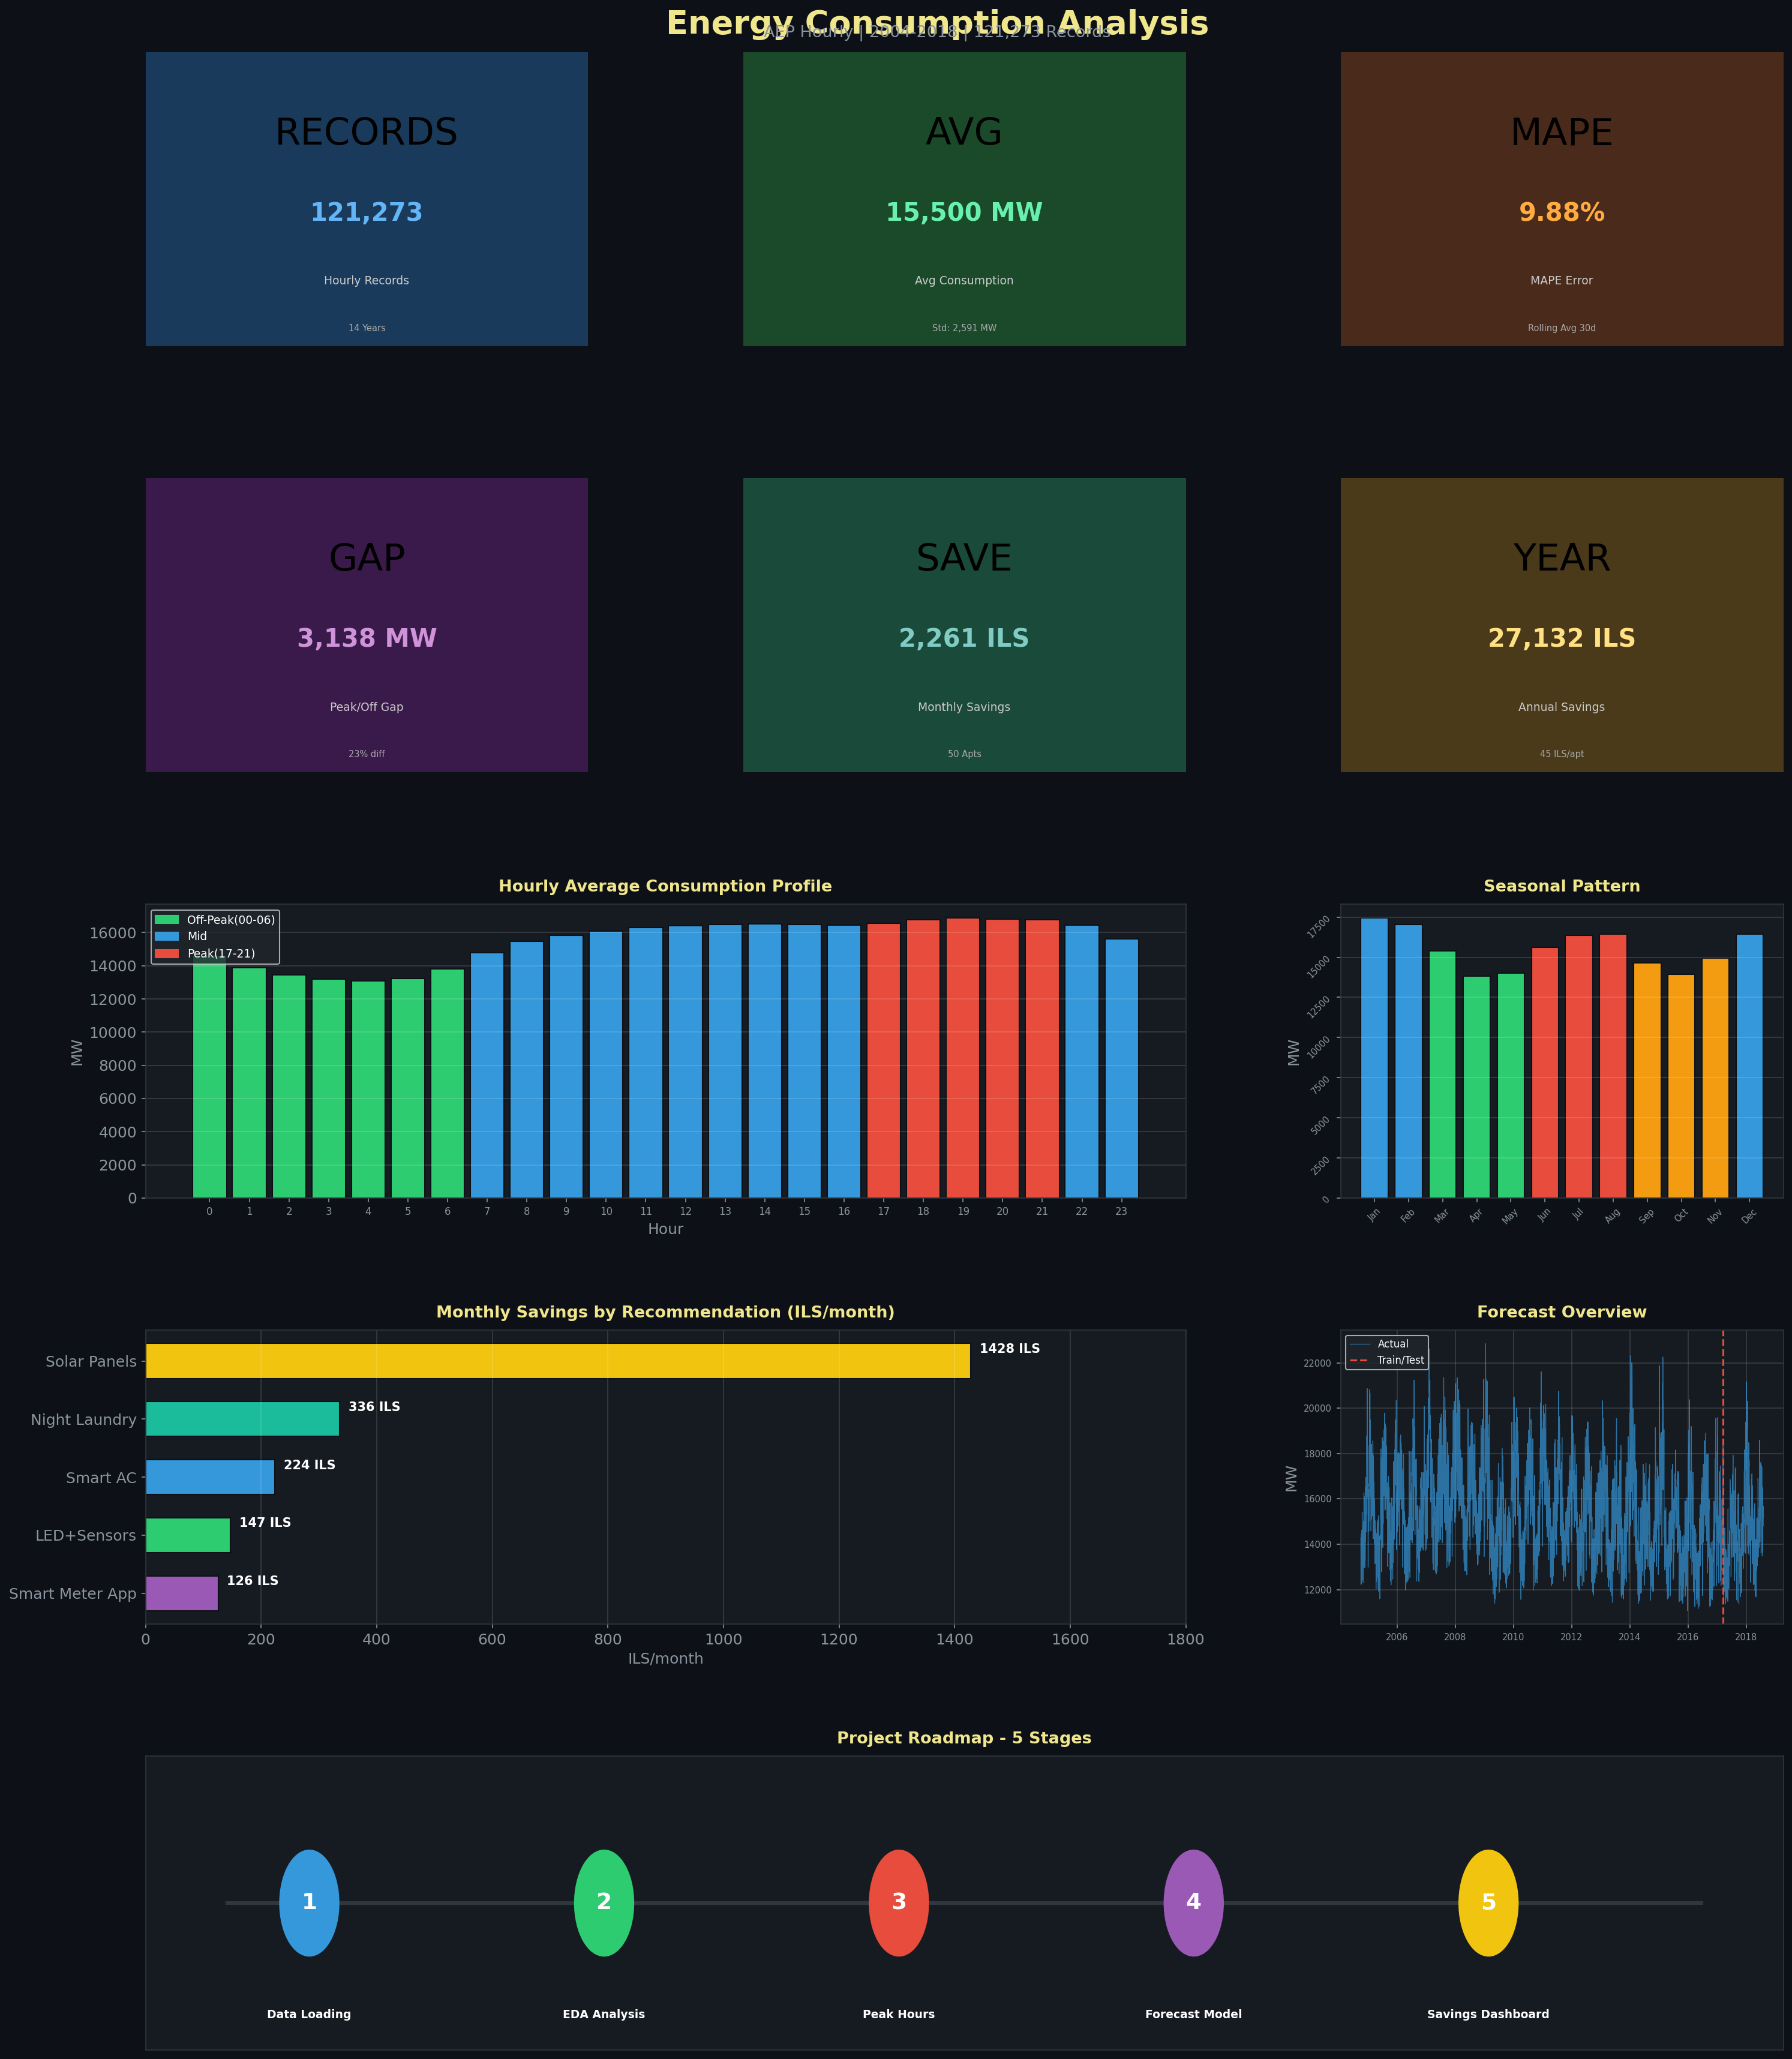

In [11]:
from IPython.display import Image
Image(r'C:\Users\alon4\energy_project_infographic.png', width=900)

In [12]:
import subprocess, os

# בדיקת git
r = subprocess.run(['git', '--version'], capture_output=True, text=True)
print(r.stdout)

# נתיב הנוטבוק
nb_path = r'C:\Users\alon4\energy_project.ipynb'
print("Notebook exists:", os.path.exists(nb_path))

git version 2.53.0.windows.1

Notebook exists: True


In [13]:
import subprocess, os, shutil

# הגדרות
repo_url = "https://github.com/AlonEichenwald/ecg-heartbeat-classifier.git"
branch = "energy-analysis"
work_dir = r"C:\Users\alon4\energy_git_upload"

# הכן תיקייה זמנית
if os.path.exists(work_dir):
        shutil.rmtree(work_dir)
    os.makedirs(work_dir)

# Clone shallow
r = subprocess.run(
        ['git', 'clone', '--depth=1', '--branch', branch, repo_url, work_dir],
        capture_output=True, text=True
)
print("Clone:", r.stdout, r.stderr[:200] if r.stderr else "")

IndentationError: unindent does not match any outer indentation level (<string>, line 11)